# 06 — Stationary distribution and aggregate moments

**Ports**: `Code/MATLAB/Steady_State_Ayagari/ComputeDistHist_open.m` plus `Code/MATLAB/Exogenous_files/basefun.m` (linear-interp weights) and `myfnder.m` (PCHIP derivative for the MPC).

**Inputs**: `../output/params.npz` (asset grids, Markov chain), `../output/egm_ss.npz` (policy functions from notebook 05).

**Outputs (saved to `../output/distribution_ss.npz`)**:
- `G0` `(nA_fine, ns)` — stationary distribution over (assets, productivity).
- `a_per_state`, `c_per_state` — aggregate $\sum_a G_0(a,j) \cdot a'(a,j)$ and $\sum_a G_0(a,j) c(a,j)$ per productivity state.
- `A_total` — total per-capita asset holdings (= sum of `a_per_state`).
- `C_total` — aggregate consumption of home good.
- `mpc_fine` `(nA_fine, ns)` — local MPC out of wealth via PCHIP derivative.
- `mpc_avg` — wealth-weighted aggregate MPC.
- `nw_quintiles_model` — wealth at each quintile cutoff (for comparison to HFCS data targets).

## Imports + load inputs

In [1]:
from pathlib import Path
import time

import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import eigs
from scipy.interpolate import PchipInterpolator
import matplotlib.pyplot as plt

OUTPUT_DIR = Path('..') / 'output'
p = np.load(OUTPUT_DIR / 'params.npz')
egm = np.load(OUTPUT_DIR / 'egm_ss.npz')

Agrid = p['params__Agrid']
Agrid_fine = p['params__Agrid_fine']
piex = p['params__piex']
ex = p['params__ex']
exinv = p['params__exinv']
nA = int(p['params__nA'])
nA_fine = int(p['params__nA_fine'])
ns = int(p['params__ns'])
y_ss = float(p['params__y_ss'])
k_ss = float(p['params__k_ss'])
b_agg_ss = float(p['params__b_agg_ss'])

cpol = egm['cpol']
c_fine = egm['c_fine']
dec_fine = egm['dec_fine']

# HFCS wealth quintile targets (per-capita kEUR; Main.m line 25)
target_nw_q = p['target__nw_quintiles']
target_gdp = float(p['target__gdp'])

print(f'nA_fine = {nA_fine}, ns = {ns}, total state size = {nA_fine * ns}')
print(f'y_ss = {y_ss:.4f}, k_ss = {k_ss:.4f}, b_agg_ss = {b_agg_ss:.4f}')
print(f'Asset-market clearing target: A_total = K + B = {k_ss + b_agg_ss:.4f}')

nA_fine = 769, ns = 7, total state size = 5383
y_ss = 3.0625, k_ss = 29.7152, b_agg_ss = -4.3432
Asset-market clearing target: A_total = K + B = 25.3719


## Linear-interpolation weights (port of `basefun.m`)

Given a fine grid of assets and a target value $x = a'(a, s)$, returns indices `(ind1, ind2)` and weights `(w1, w2)` such that $x \approx w_1 \cdot \text{grid}[ind_1] + w_2 \cdot \text{grid}[ind_2]$ with $w_1 + w_2 = 1$. We do this for every $(i, j)$ pair in a single vectorised pass.

In [2]:
def basefun_vec(grid, x):
    """Vectorised linear-interp weights & indices for `x` against a sorted `grid`.

    Returns (ind1, ind2, w1, w2) with each shape == x.shape; ind2 = ind1 + 1.
    Weights are clamped to [0, 1] so out-of-range x gets clipped to the
    nearest endpoint (matching basefun.m).
    """
    n = grid.size
    # MATLAB: ind1 = max(1, min(n-1, sum(grid<=x)));  in 1-indexing
    # In 0-indexed numpy: searchsorted(grid, x, side='right') - 1, clamped to [0, n-2]
    ind1 = np.searchsorted(grid, x, side='right') - 1
    ind1 = np.clip(ind1, 0, n - 2)
    ind2 = ind1 + 1
    w2 = (x - grid[ind1]) / (grid[ind2] - grid[ind1])
    w2 = np.clip(w2, 0.0, 1.0)
    w1 = 1.0 - w2
    return ind1, ind2, w1, w2

## Build the sparse transition matrix

The state is $(a, s)$ with $a \in$ `Agrid_fine` and $s \in \{0, \dots, n_s-1\}$. Flatten to a single index $i + j \cdot n_{A,\text{fine}}$ as in MATLAB.

From state $(i, j)$, the household chooses $a' = $ `dec_fine[i, j]`, splits between two adjacent fine-grid points with `basefun` weights $(w_1, w_2)$, and receives a productivity draw $j'$ with probability `piex[j, j']`. So
$$T[(i, j) \to (i', j')] = \pi(j' \mid j) \cdot w_k\quad\text{for the two adjacent }i'.$$
Total non-zero entries: $n_{A,\text{fine}} \cdot n_s \cdot n_s \cdot 2$.

In [3]:
tic = time.time()
ind1, ind2, w1, w2 = basefun_vec(Agrid_fine, dec_fine)  # each (nA_fine, ns)

# Pre-build the full (nA_fine, ns) → (nA_fine, ns) sparse transition
# in COO format. Vectorised over (i, j, jp) using broadcasting.
i_idx = np.arange(nA_fine)
j_idx = np.arange(ns)
jp_idx = np.arange(ns)

# Source flat index: i + j * nA_fine, shape (nA_fine, ns)
src = i_idx[:, None] + j_idx[None, :] * nA_fine

# For each (i, j, jp), two destination flat indices and two probability weights.
# Broadcasting: (nA_fine, ns, 1) op (1, 1, ns) -> (nA_fine, ns, ns)
ind1_b = ind1[:, :, None]   # (nA_fine, ns, 1)
ind2_b = ind2[:, :, None]
w1_b = w1[:, :, None]
w2_b = w2[:, :, None]
piex_b = piex[None, :, :]   # (1, ns, ns)  -- piex[j, jp]
src_b = src[:, :, None]     # (nA_fine, ns, 1)

# Destination 1: ind1 + jp * nA_fine
dst1 = ind1_b + jp_idx[None, None, :] * nA_fine
val1 = piex_b * w1_b
dst2 = ind2_b + jp_idx[None, None, :] * nA_fine
val2 = piex_b * w2_b

rows = np.concatenate([
    np.broadcast_to(src_b, (nA_fine, ns, ns)).ravel(),
    np.broadcast_to(src_b, (nA_fine, ns, ns)).ravel(),
])
cols = np.concatenate([dst1.ravel(), dst2.ravel()])
vals = np.concatenate([val1.ravel(), val2.ravel()])

N = nA_fine * ns
transMat = sp.coo_matrix((vals, (rows, cols)), shape=(N, N)).tocsr()

elapsed = time.time() - tic
print(f'Transition matrix built in {elapsed:.2f} s')
print(f'  shape : {transMat.shape}')
print(f'  nnz   : {transMat.nnz} (expected: {nA_fine * ns * ns * 2})')
print(f'  Row sums (sample): {np.asarray(transMat.sum(axis=1)).ravel()[:5]}')
row_sums = np.asarray(transMat.sum(axis=1)).ravel()
assert np.allclose(row_sums, 1.0, atol=1e-10), 'transMat must be row-stochastic'

Transition matrix built in 0.00 s
  shape : (5383, 5383)
  nnz   : 75362 (expected: 75362)
  Row sums (sample): [1. 1. 1. 1. 1.]


## Stationary distribution

MATLAB uses `eigs(transMat', 1)` — i.e. the dominant eigenvector of $T^\top$ with eigenvalue 1. Same in Python via `scipy.sparse.linalg.eigs`.

In [4]:
tic = time.time()
vals, vecs = eigs(transMat.T.tocsr(), k=1, which='LM', tol=1e-12, maxiter=10_000)
EigVec = np.real(vecs[:, 0])
eig_eigenvalue = float(np.real(vals[0]))
EigVec = EigVec / EigVec.sum()
EigVec[EigVec < 0] = 0.0  # numerical noise can give tiny negatives
EigVec = EigVec / EigVec.sum()
G0 = EigVec.reshape((ns, nA_fine)).T  # match MATLAB reshape([nA_fine ns])
elapsed = time.time() - tic

print(f'Largest eigenvalue: {eig_eigenvalue:.10f}  (should be 1.0)')
print(f'G0 sums to {G0.sum():.10f}')
print(f'Time: {elapsed:.2f} s')

# Cross-check: marginal distribution over productivity should equal exinv
marg_s = G0.sum(axis=0)
print('\nMarginal over productivity (model vs. exinv):')
for j in range(ns):
    print(f'  j={j}: model={marg_s[j]:.6f}, exinv={exinv[j]:.6f}, diff={marg_s[j]-exinv[j]:.2e}')

Largest eigenvalue: 1.0000000000  (should be 1.0)
G0 sums to 1.0000000000
Time: 0.06 s

Marginal over productivity (model vs. exinv):
  j=0: model=0.015625, exinv=0.015625, diff=1.05e-14
  j=1: model=0.093750, exinv=0.093750, diff=4.50e-14
  j=2: model=0.234375, exinv=0.234375, diff=6.15e-14
  j=3: model=0.312500, exinv=0.312500, diff=-8.88e-16
  j=4: model=0.234375, exinv=0.234375, diff=-6.18e-14
  j=5: model=0.093750, exinv=0.093750, diff=-4.50e-14
  j=6: model=0.015625, exinv=0.015625, diff=-9.14e-15


## Aggregate moments

MATLAB:
```matlab
a = sum(G0.*dec_fine, 1);   % aggregate next-period assets per productivity
c = sum(G0.*c_fine, 1);     % aggregate consumption per productivity
A = sum(a);                 % total per-capita assets
```
Asset-market clearing residual (calibrate_beta_open_tg.m line 46): `BGss + Kss - A`. With $\beta = 0.9832$ (Main.m warm start) we expect this to be tiny.

In [5]:
a_per_state = (G0 * dec_fine).sum(axis=0)
c_per_state = (G0 * c_fine).sum(axis=0)
A_total = a_per_state.sum()
C_total = c_per_state.sum()

print(f'A_total (asset demand)        = {A_total:.6f}')
print(f'B_target + K_target           = {b_agg_ss + k_ss:.6f}')
print(f'Residual (BGss + Kss - A)     = {b_agg_ss + k_ss - A_total:.6f}')
print(f'Relative residual (% of K+B)  : {(b_agg_ss + k_ss - A_total) / (b_agg_ss + k_ss) * 100:.4f}%')
print(f'C_total (home-good consumption) = {C_total:.6f}')
print(f'Implied K/Y                  : {(A_total - b_agg_ss) / y_ss:.4f}  (target {p["params__k_y_ss"]:.4f})')

A_total (asset demand)        = 25.247010
B_target + K_target           = 25.371939
Residual (BGss + Kss - A)     = 0.124929
Relative residual (% of K+B)  : 0.4924%
C_total (home-good consumption) = 1.452503
Implied K/Y                  : 9.6620  (target 9.7028)


## MPC out of wealth via PCHIP derivative

MATLAB uses `myfnder` to differentiate the PCHIP fit of `cpol(:, j)` w.r.t. assets, evaluated on the fine grid. SciPy's `PchipInterpolator(...).derivative()` is the direct equivalent.

In [6]:
mpc_fine = np.zeros((nA_fine, ns))
for j in range(ns):
    interp = PchipInterpolator(Agrid, cpol[:, j], extrapolate=True)
    mpc_fine[:, j] = interp.derivative()(Agrid_fine)

mpc_per_state = (G0 * mpc_fine).sum(axis=0)
mpc_avg = mpc_per_state.sum()

print(f'Aggregate MPC (avg over households): {mpc_avg:.6f}')
print('MPC by productivity state:')
for j in range(ns):
    pop_j = G0[:, j].sum()
    avg_j = mpc_per_state[j] / pop_j if pop_j > 0 else 0.0
    print(f'  j={j}, e={ex[j]:.3f}, pop={pop_j:.4f}, MPC={avg_j:.4f}')

Aggregate MPC (avg over households): 0.109038
MPC by productivity state:
  j=0, e=0.090, pop=0.0156, MPC=0.4040
  j=1, e=0.179, pop=0.0938, MPC=0.3483
  j=2, e=0.356, pop=0.2344, MPC=0.2393
  j=3, e=0.707, pop=0.3125, MPC=0.0280
  j=4, e=1.405, pop=0.2344, MPC=0.0163
  j=5, e=2.789, pop=0.0937, MPC=0.0131
  j=6, e=5.537, pop=0.0156, MPC=0.0117


## Wealth quintiles vs. HFCS targets

Reproduces `Main.m` lines 292-301. The HFCS quintiles (per-capita kEUR) are
`[0.9, 13, 26.2, 48.6, 84.1, 160.6]`; the cumulative cutoffs in the MATLAB code are
`Quintile = [0.1, 0.3, 0.5, 0.7, 0.85, 0.95]` (the 10th, 30th, 50th, 70th, 85th, 95th percentile of the wealth distribution).

In [7]:
quint_cutoffs = np.array([0.1, 0.3, 0.5, 0.7, 0.85, 0.95])
marg_a = G0.sum(axis=1)            # marginal over productivity
cum_a = np.cumsum(marg_a)
indices = [int(np.argmax(cum_a > q)) for q in quint_cutoffs]
model_q = np.array([Agrid_fine[i] for i in indices])
model_q_to_gdp = model_q / y_ss   # MATLAB reports model_nw / y_ss (quarterly)
target_q_to_gdp = target_nw_q / target_gdp

print(f'{"Quintile":<12s}{"Model NW/qGDP":<15s}{"HFCS target":<15s}')
for q, m, t in zip(quint_cutoffs, model_q_to_gdp, target_q_to_gdp):
    print(f'  {q:<10.2f}{m:<15.4f}{t:<15.4f}')

Quintile    Model NW/qGDP  HFCS target    
  0.10      -0.0000        0.2846         
  0.30      0.4499         4.1107         
  0.50      2.9399         8.2846         
  0.70      8.3929         15.3676        
  0.85      17.5471        26.5929        
  0.95      34.8016        50.7826        


## Visualise the stationary distribution

Mass concentrates between the borrowing constraint and a moderate positive asset level. Tail to the right: high-productivity savers.

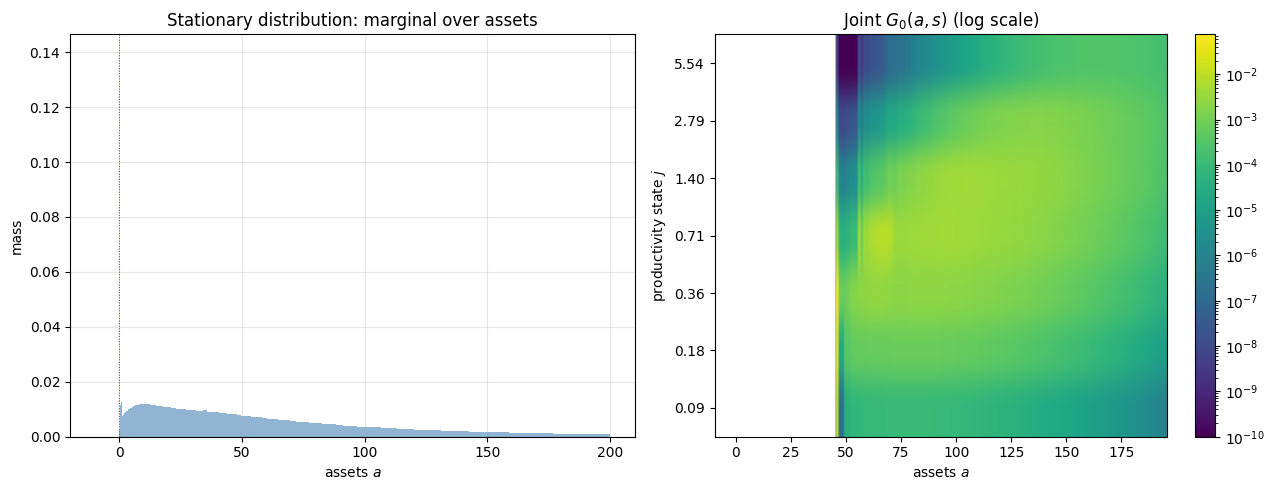

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Marginal over assets
vis_max = 200.0
vis_mask = (Agrid_fine >= -10) & (Agrid_fine <= vis_max)
axes[0].bar(
    Agrid_fine[vis_mask],
    marg_a[vis_mask],
    width=np.diff(np.append(Agrid_fine[vis_mask], vis_max)),
    align='edge', alpha=0.6, color='steelblue'
)
axes[0].set_xlabel('assets $a$')
axes[0].set_ylabel('mass')
axes[0].set_title('Stationary distribution: marginal over assets')
axes[0].axvline(0, color='red', lw=0.7, ls=':')
axes[0].grid(True, alpha=0.3)

# Joint distribution (heatmap, log scale)
import matplotlib.colors as mcolors
asset_idx = np.where(vis_mask)[0]
G0_vis = G0[asset_idx, :]
im = axes[1].imshow(
    G0_vis.T,
    aspect='auto',
    extent=[Agrid_fine[asset_idx[0]], Agrid_fine[asset_idx[-1]], -0.5, ns - 0.5],
    origin='lower',
    norm=mcolors.LogNorm(vmin=max(G0_vis.min(), 1e-10), vmax=G0_vis.max()),
    cmap='viridis'
)
axes[1].set_xlabel('assets $a$')
axes[1].set_ylabel('productivity state $j$')
axes[1].set_yticks(range(ns))
axes[1].set_yticklabels([f'{ex[j]:.2f}' for j in range(ns)])
axes[1].set_title('Joint $G_0(a, s)$ (log scale)')
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()

## Save outputs

In [9]:
out_path = OUTPUT_DIR / 'distribution_ss.npz'
np.savez(
    out_path,
    G0=G0,
    a_per_state=a_per_state,
    c_per_state=c_per_state,
    A_total=A_total,
    C_total=C_total,
    mpc_fine=mpc_fine,
    mpc_per_state=mpc_per_state,
    mpc_avg=mpc_avg,
    nw_quintiles_model=model_q,
    nw_quintiles_target=target_nw_q,
    asset_market_residual=b_agg_ss + k_ss - A_total,
    eigenvalue=eig_eigenvalue,
)
print(f'Saved: {out_path.resolve()}')

Saved: /Users/siyingli/github/de-Ferra2020-kz/Code/Python/output/distribution_ss.npz
